# Retea Neuronala MLP – Rezistenta Betonului

Scopul: sa invatam un model sa prezica **rezistenta betonului (MPa)** in functie de ingredientele amestecului.

Vom testa **8 configuratii** diferite, variind:
- Numarul de **straturi ascunse**: 1 sau 2
- Numarul de **neuroni pe strat**: egal cu stratul anterior sau jumatate
- **Learning rate** (cat de repede invata reteaua): 0.1 sau 0.01

**Metrica folosita: MAE** (Mean Absolute Error) = eroarea medie in MPa. Cu cat mai mic, cu atat mai bine.

In [5]:
# Importam librariile necesare
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
from itertools import product


## 1. Incarcarea datelor

In [6]:
df = pd.read_csv('Concrete_Data.csv')

# Redenumim coloanele ca sa fie mai usor de citit
df.columns = [
    'Ciment', 'Zgura', 'Cenusa_Zbor',
    'Apa', 'Superplastifiant', 'Agreg_Grosier',
    'Agreg_Fin', 'Varsta_Zile', 'Rezistenta_MPa'
]

print(f'dataset: {df.shape[0]}, features:{df.shape[1]-1}')
print(f'target: Rezistenta_MPa')
display(df.head())

display(df.describe().round(2))


dataset: 1030, features:8
target: Rezistenta_MPa


,Ciment,Zgura,Cenusa_Zbor,Apa,Superplastifiant,Agreg_Grosier,Agreg_Fin,Varsta_Zile,Rezistenta_MPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


,Ciment,Zgura,Cenusa_Zbor,Apa,Superplastifiant,Agreg_Grosier,Agreg_Fin,Varsta_Zile,Rezistenta_MPa
count,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00
mean,281.17,73.90,54.19,181.57,6.20,972.92,773.58,45.66,35.82
std,104.51,86.28,64.00,21.35,5.97,77.75,80.18,63.17,16.71
min,102.00,0.00,0.00,121.80,0.00,801.00,594.00,1.00,2.33
25%,192.38,0.00,0.00,164.90,0.00,932.00,730.95,7.00,23.71
50%,272.90,22.00,0.00,185.00,6.40,968.00,779.50,28.00,34.44
75%,350.00,142.95,118.30,192.00,10.20,1029.40,824.00,56.00,46.14
max,540.00,359.40,200.10,247.00,32.20,1145.00,992.60,365.00,82.60


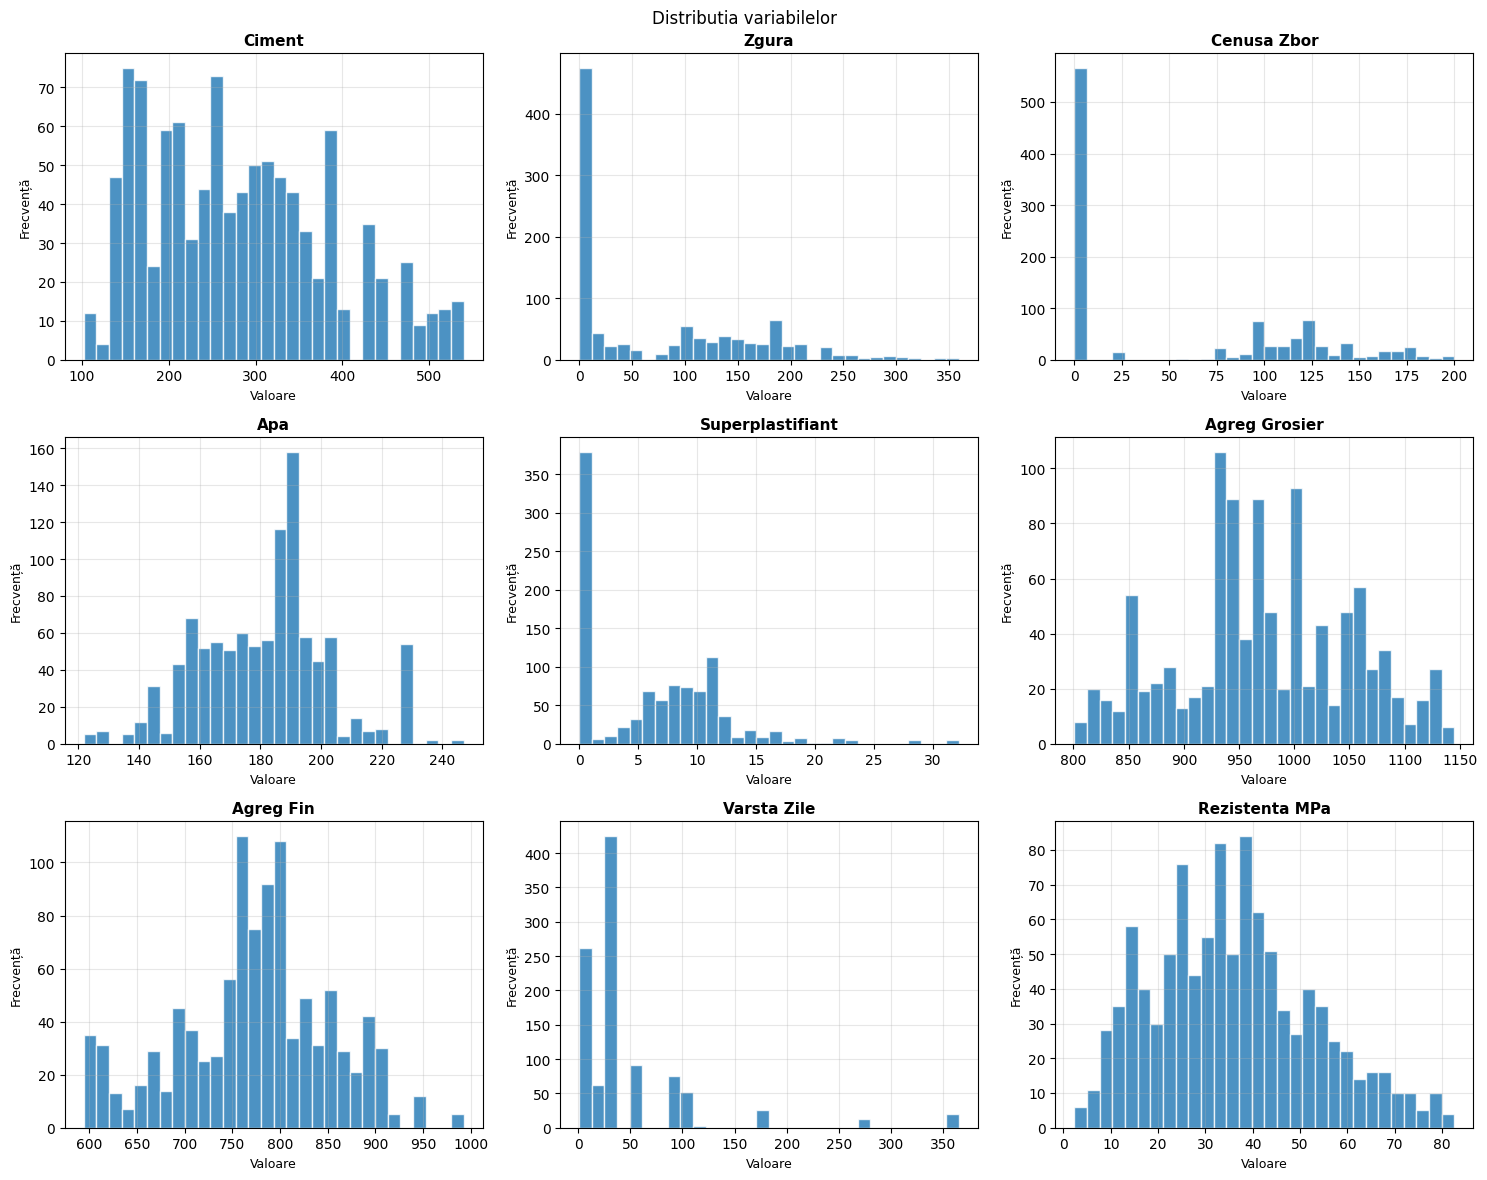

In [7]:

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distributia variabilelor')


for i in range(len(df.columns)):
    col = df.columns[i]
    ax = axes.flatten()[i]

    ax.hist(df[col], bins=30, alpha=0.8, edgecolor='white')
    ax.set_title(col.replace('_', ' '), fontsize=11, fontweight='bold')
    ax.set_xlabel('Valoare', fontsize=9)
    ax.set_ylabel('Frecvență', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


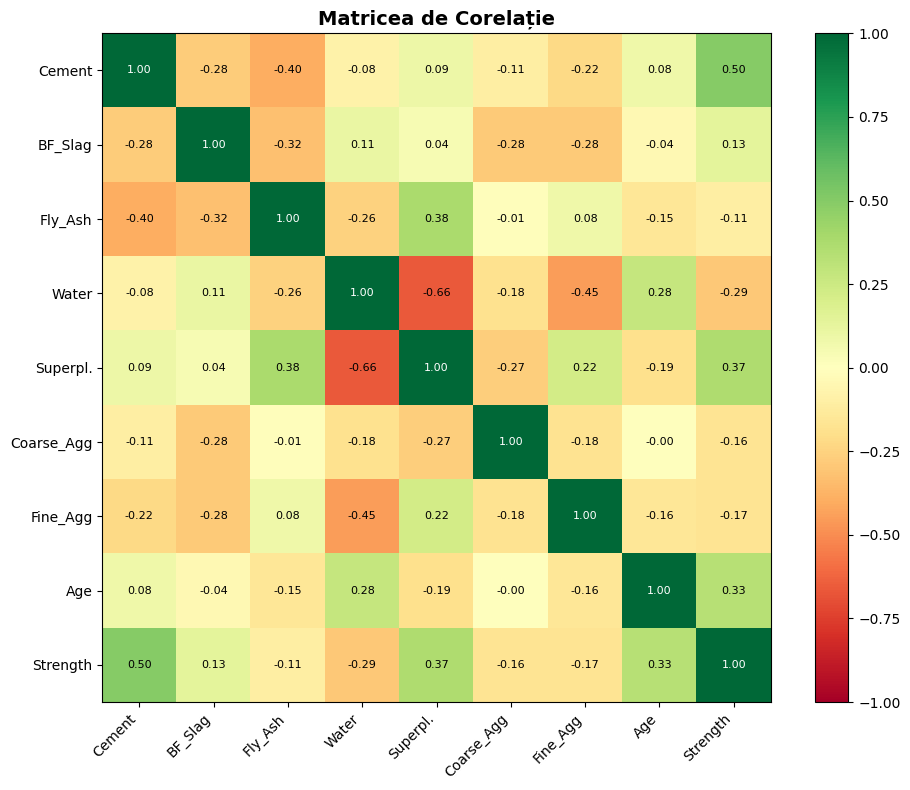

In [8]:
# Matricea de corelatie
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df.corr()
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

cols_short = ['Cement', 'BF_Slag', 'Fly_Ash', 'Water', 'Superpl.', 
              'Coarse_Agg', 'Fine_Agg', 'Age', 'Strength']
ax.set_xticks(range(len(cols_short)))
ax.set_yticks(range(len(cols_short)))
ax.set_xticklabels(cols_short, rotation=45, ha='right')
ax.set_yticklabels(cols_short)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                ha='center', va='center', fontsize=8,
                color='black' if abs(corr_matrix.iloc[i, j]) < 0.7 else 'white')

ax.set_title('Matricea de Corelație', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('corelatie.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Pregatirea datelor

- Impartim datele: **80% pentru antrenament**, 20% pentru testare
- **Normalizam** valorile (StandardScaler) – reteaua neurala invata mai bine cand toate valorile sunt pe aceeasi scara

In [9]:
X = df.drop('Rezistenta_MPa', axis=1)
y = df['Rezistenta_MPa']

n_input = X.shape[1]  # 8 variabile de intrare

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

print(f'Date antrenament : {X_train_sc.shape[0]} exemple')
print(f'Date test        : {X_test_sc.shape[0]} exemple')
print('Normalizare aplicata!')

Date antrenament : 824 exemple
Date test        : 206 exemple
Normalizare aplicata!


## 3. Definirea configuratiilor

Pornim cu **8 neuroni** pe primul strat (egal cu numarul de variabile de intrare).

| Schema neuroni | 1 strat ascuns | 2 straturi ascunse |
|---|---|---|
| **Egal** | (8,) | (8, 8) |
| **Jumatate** | (8,) | (8, 4) |

In [10]:
def construieste_straturi(n_straturi, schema, primul_strat):
    straturi = [primul_strat]
    for _ in range(1, n_straturi):
        if schema == 'egal':
            straturi.append(straturi[-1])
        else:  # jumatate
            straturi.append(max(1, straturi[-1] // 2))
    return tuple(straturi)



## 4. Antrenarea modelelor

Antrenam cate un model MLP pentru fiecare configuratie si masuram **MAE** pe datele de test.

In [11]:
rezultate = []
combinatii = [
    (1, 'egal',   0.1),   
    (1, 'egal',   0.01),  
    (2, 'egal',   0.1),   
    (2, 'egal',   0.01),  
    (2, 'jumate', 0.1),   
    (2, 'jumate', 0.01)   
]

for i, (straturi, schema, lr) in enumerate(combinatii):

    if straturi == 1:
        layers = (8)
    else:
        if schema == 'egal':
            layers = (8, 8)
        else:
            layers = (8, 4)

    model = MLPRegressor(
        hidden_layer_sizes=layers,
        activation='relu',        
        solver='adam',            
        learning_rate_init=lr,
        early_stopping=True,     
        random_state=42
    )

    model.fit(X_train_sc, y_train_sc)

    y_pred_sc = model.predict(X_test_sc)
    y_pred = scaler_y.inverse_transform(y_pred_sc.reshape(-1, 1))
    y_pred=y_pred.reshape(-1)

    mae = mean_absolute_error(y_test, y_pred)

    rezultate.append({
        'Nr': i,
        'N_Straturi': straturi,
        'Arhitectura': layers,
        'LR': lr,
        'MAE': mae,
        'Epoci': model.n_iter_,
        'Loss_Curve': model.loss_curve_
    })


rez = pd.DataFrame(rezultate)


## 5. Rezultate – Cel mai bun si cel mai slab model

In [12]:
best_idx  = rez['MAE'].idxmin()
best  = rez.iloc[best_idx]

print(f'Cel mai bun model:')
print(f'  Arhitectura  : {best["Arhitectura"]}')
print(f'  Learning Rate: {best["LR"]}')
print(f'  MAE          : {best["MAE"]:.3f} MPa')

Cel mai bun model:
  Arhitectura  : (8, 4)
  Learning Rate: 0.01
  MAE          : 4.670 MPa


## 6. Grafice

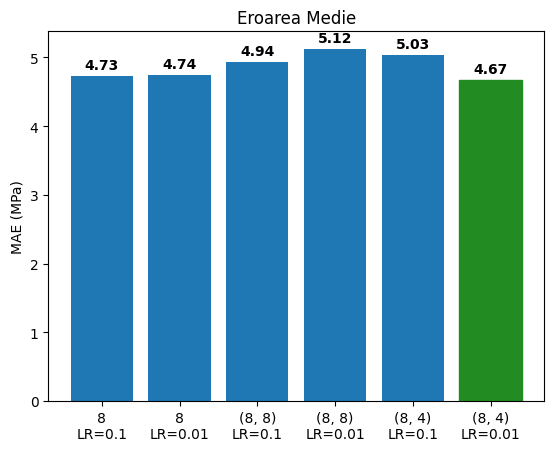

In [13]:
etichete = [1,2,3,4,5,6]
etichete = rez['Arhitectura'].astype(str) + "\nLR=" + rez['LR'].astype(str)
bare = plt.bar(etichete, rez['MAE'])
bare[best_idx].set_color('forestgreen')

plt.bar_label(bare, fmt='%.2f', padding=3, fontweight='bold')

plt.ylabel('MAE (MPa)')
plt.title('Eroarea Medie')

plt.show()

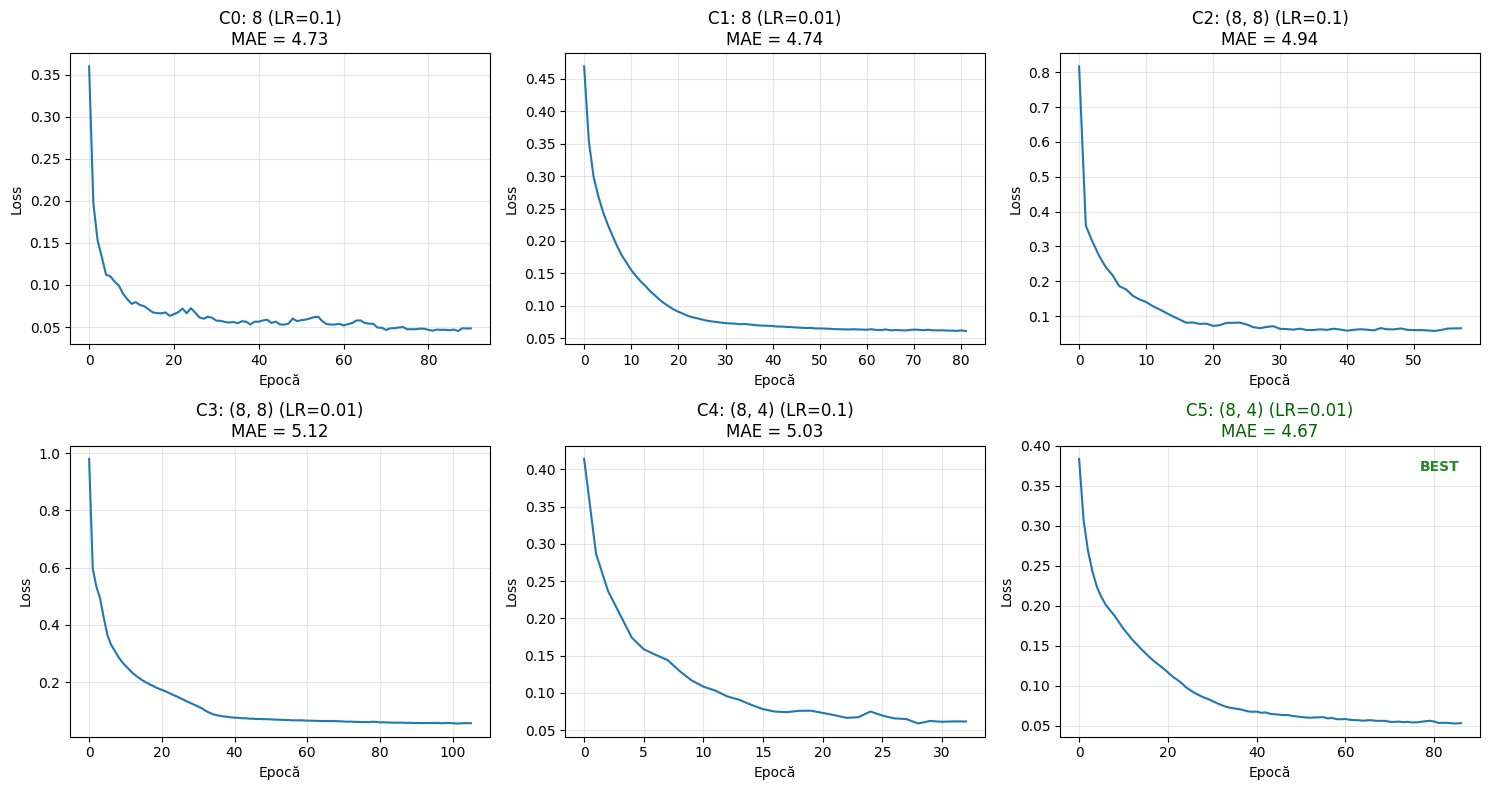

In [14]:

fig, axes = plt.subplots(2,3, figsize=(15, 8))

axe_lista = axes.flatten()

for idx, rand in rez.iterrows():
    ax = axe_lista[idx]
    
    
    # Desenăm linia
    ax.plot(rand['Loss_Curve'])
    
    # Titlul fiecărui sub-grafic 
    rez['Arhitectura'].astype(str) + "\nLR=" + rez['LR'].astype(str)
    titlu = f"C{rand['Nr']}: {rand['Arhitectura']} (LR={rand['LR']})\nMAE = {rand['MAE']:.2f}"
    ax.set_title(titlu, color='darkgreen' if idx == best_idx else 'black')
    
    ax.set_xlabel('Epocă')
    ax.set_ylabel('Loss')
    ax.grid(alpha=0.3)
    
    # Eticheta 'BEST' scrisă explicit (cu argumentele x, y, s)
    if idx == best_idx:
        ax.text(x=0.95, y=0.95, s='BEST', transform=ax.transAxes, 
                ha='right', va='top', color='forestgreen', fontweight='bold')

plt.tight_layout()
plt.show()